\# Task 5 — Phase 2: LCMA Loss + Augmentation
**MirrorSpeech** | Shreya Akotiya

**Run locally on Mac (Apple M5, MPS accelerated)**

This notebook implements:
1. **LCMA Loss** — MSE between original content vector and re-encoded content vector (with β tuning)
2. **Pitch Shift Augmentation** — randomly shifts pitch ±2 semitones
3. **Speed Perturbation** — random speed between 0.9× and 1.1×
4. **SpecAugment** — randomly masks frequency bands and time steps
5. **Class Imbalance Handling** — WeightedRandomSampler to balance 5 accent classes
6. **Verification** — shows LCMA loss decreasing, visualizes augmented spectrograms

**Local paths (Scripts/ folder):**
- Splits: `Scripts /splits/`
- L2-ARCTIC: `Scripts /l2arctic/`
- LibriSpeech: `Scripts /librispeech/`
- Output: `Scripts /checkpoints/task5_lcma_augmentation.pt`

---
## Step 0 — Install packages (run once in terminal if needed)
```bash
pip install torch torchaudio transformers peft soundfile matplotlib numpy
```

In [ ]:
import subprocess, sys
# Only install if missing
pkgs = ['torch', 'torchaudio', 'transformers', 'peft', 'soundfile']
for pkg in pkgs:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All packages available.')

All packages available.


In [ ]:
pip install --upgrade torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.


---
## Step 1 — Imports + Device

In [ ]:
import os, json, random

# Unset watermark env vars that cause MPS conflicts, then force CPU
os.environ.pop('PYTORCH_MPS_HIGH_WATERMARK_RATIO', None)
os.environ.pop('PYTORCH_MPS_LOW_WATERMARK_RATIO', None)

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Force CPU — MPS runs OOM with Whisper-small on shared 24GB RAM
device = torch.device('cpu')

print(f'PyTorch    : {torch.__version__}')
print(f'Torchaudio : {torchaudio.__version__}')
print(f'Device     : {device}')

PyTorch    : 2.2.2
Torchaudio : 2.2.2
Device     : cpu


---
## Step 2 — Set Local Paths

In [ ]:
import pathlib

# Base = this notebook's folder (Scripts /)
BASE_DIR      = pathlib.Path(__file__).parent if '__file__' in dir() else pathlib.Path.cwd()
# If running from project root, adjust:
if not (BASE_DIR / 'splits').exists():
    BASE_DIR = BASE_DIR / 'Scripts '

SPLITS_DIR    = str(BASE_DIR / 'splits')
EXTRACT_PATH  = str(BASE_DIR / 'l2arctic')
LIBRISPEECH_PATH = str(BASE_DIR / 'librispeech')
CKPT_DIR      = str(BASE_DIR / 'checkpoints')

os.makedirs(CKPT_DIR, exist_ok=True)

print(f'Splits dir    : {SPLITS_DIR}')
print(f'L2-ARCTIC dir : {EXTRACT_PATH}')
print(f'LibriSpeech   : {LIBRISPEECH_PATH}')
print(f'Checkpoints   : {CKPT_DIR}')

# Verify splits exist
for split in ['train.json', 'val.json', 'test.json', 'config.json']:
    path = os.path.join(SPLITS_DIR, split)
    status = '✅' if os.path.exists(path) else '❌ MISSING'
    print(f'  {split}: {status}')

Splits dir    : /Users/shreya/SJSU-Github/Deep_Learning_Project/Scripts /splits
L2-ARCTIC dir : /Users/shreya/SJSU-Github/Deep_Learning_Project/Scripts /l2arctic
LibriSpeech   : /Users/shreya/SJSU-Github/Deep_Learning_Project/Scripts /librispeech
Checkpoints   : /Users/shreya/SJSU-Github/Deep_Learning_Project/Scripts /checkpoints
  train.json: ✅
  val.json: ✅
  test.json: ✅
  config.json: ✅


---
## Step 3 — Check LibriSpeech (already downloaded locally)

In [ ]:
if os.path.exists(LIBRISPEECH_PATH):
    flac_count = sum(1 for _, _, files in os.walk(LIBRISPEECH_PATH) for f in files if f.endswith('.flac'))
    print(f'✅ LibriSpeech found at {LIBRISPEECH_PATH}')
    print(f'   {flac_count:,} FLAC files')
else:
    print(f'LibriSpeech not found at {LIBRISPEECH_PATH}')
    print('Downloading dev-clean (~344 MB)...')
    os.makedirs(LIBRISPEECH_PATH, exist_ok=True)
    _libri = torchaudio.datasets.LIBRISPEECH(root=LIBRISPEECH_PATH, url='dev-clean', download=True)
    print(f'✅ Downloaded: {len(_libri):,} utterances')

✅ LibriSpeech found at /Users/shreya/SJSU-Github/Deep_Learning_Project/Scripts /librispeech
   5,406 FLAC files


---
## Step 4 — Load Splits + Fix Paths

In [ ]:
def load_and_fix_paths(split_name):
    records = json.load(open(f'{SPLITS_DIR}/{split_name}.json'))
    for r in records:
        orig = r['wav_path'].replace('\\', '/')
        if 'librispeech' in orig.lower():
            # Find the tail after 'librispeech/'
            tail = orig.split('librispeech/', 1)[-1]
            r['wav_path'] = os.path.join(LIBRISPEECH_PATH, tail)
        else:
            r['wav_path'] = os.path.join(
                EXTRACT_PATH, r['speaker'], 'wav', os.path.basename(orig)
            )
    return records

config        = json.load(open(f'{SPLITS_DIR}/config.json'))
train_records = load_and_fix_paths('train')
val_records   = load_and_fix_paths('val')
test_records  = load_and_fix_paths('test')

ACCENT_MAP         = {int(k): v for k, v in config['id_to_accent'].items()}
ACCENT_TO_ID       = {v: k for k, v in ACCENT_MAP.items()}
NUM_ACCENT_CLASSES = int(config.get('num_accent_classes', len(ACCENT_MAP)))
TARGET_SR          = int(config.get('target_sample_rate', 16000))

print('=== DATASET ===')
print(f'Train : {len(train_records):,}')
print(f'Val   : {len(val_records):,}')
print(f'Test  : {len(test_records):,}')
print(f'Accent classes: {NUM_ACCENT_CLASSES}')
print('\nAccent distribution (train):')
for aid, cnt in sorted(Counter(r['accent_id'] for r in train_records).items()):
    print(f'  {ACCENT_MAP[aid]:10s} (id={aid}): {cnt:,}')

# Verify a few paths resolve
missing = sum(1 for r in train_records[:200] if not os.path.exists(r['wav_path']))
print(f'\nPath check (first 200): {200-missing}/200 files found')

=== DATASET ===
Train : 14,829
Val   : 1,853
Test  : 1,855
Accent classes: 5

Accent distribution (train):
  indian     (id=0): 3,599
  mandarin   (id=1): 3,649
  korean     (id=2): 2,728
  arabic     (id=3): 2,686
  native     (id=4): 2,167

Path check (first 200): 200/200 files found


---
## Step 5 — Augmentation Functions

Three augmentations applied **only during training**:

| Augmentation | What it does | Why |
|---|---|---|
| **Pitch Shift** | Shifts pitch ±2 semitones randomly | Simulates speaker variability |
| **Speed Perturbation** | Speeds up/slows down audio 0.9×–1.1× | Simulates speaking rate variation |
| **SpecAugment** | Masks frequency bands and time steps | Forces model to be robust to missing info |

In [ ]:
# ── Pitch Shift ──────────────────────────────────────────────────
def pitch_shift_augment(waveform, sample_rate, n_steps_range=(-2, 2)):
    """
    Randomly shifts pitch by n semitones.
    n_steps_range: (min, max) semitones — e.g. (-2, 2) means -2 to +2 semitones.
    """
    n_steps = random.uniform(*n_steps_range)
    transform = T.PitchShift(sample_rate=sample_rate, n_steps=n_steps)
    return transform(waveform)


# ── Speed Perturbation ────────────────────────────────────────────
def speed_perturb_augment(waveform, sample_rate, speed_range=(0.9, 1.1)):
    """
    Randomly speeds up or slows down audio.
    speed_range: (min, max) — 0.9 = 10% slower, 1.1 = 10% faster.
    """
    speed_factor = random.uniform(*speed_range)
    transform    = T.Speed(orig_freq=sample_rate, factor=speed_factor)
    waveform_out, _ = transform(waveform)
    # Resample back to original length's sample rate
    new_sr = int(sample_rate * speed_factor)
    if new_sr != sample_rate:
        waveform_out = T.Resample(new_sr, sample_rate)(waveform_out)
    return waveform_out


# ── SpecAugment ───────────────────────────────────────────────────
def spec_augment(spectrogram, freq_mask_param=15, time_mask_param=50, num_freq_masks=2, num_time_masks=2):
    """
    Applies SpecAugment on a log-mel spectrogram [80, T].
    freq_mask_param : max frequency bins to mask per mask
    time_mask_param : max time frames to mask per mask
    num_freq_masks  : how many frequency masks to apply
    num_time_masks  : how many time masks to apply
    """
    spec = spectrogram.clone()
    freq_masker = T.FrequencyMasking(freq_mask_param=freq_mask_param)
    time_masker = T.TimeMasking(time_mask_param=time_mask_param)
    for _ in range(num_freq_masks):
        spec = freq_masker(spec)
    for _ in range(num_time_masks):
        spec = time_masker(spec)
    return spec


print('✅ Augmentation functions defined:')
print('  pitch_shift_augment()   — waveform-level, ±2 semitones')
print('  speed_perturb_augment() — waveform-level, 0.9×–1.1×')
print('  spec_augment()          — spectrogram-level, freq + time masking')

✅ Augmentation functions defined:
  pitch_shift_augment()   — waveform-level, ±2 semitones
  speed_perturb_augment() — waveform-level, 0.9×–1.1×
  spec_augment()          — spectrogram-level, freq + time masking


---
## Step 6 — Test Augmentations on a Real Sample
Visualize original vs augmented spectrogram to confirm they work.

Testing augmentations on: NJS — "Last night he showed all the symptoms of coming do"


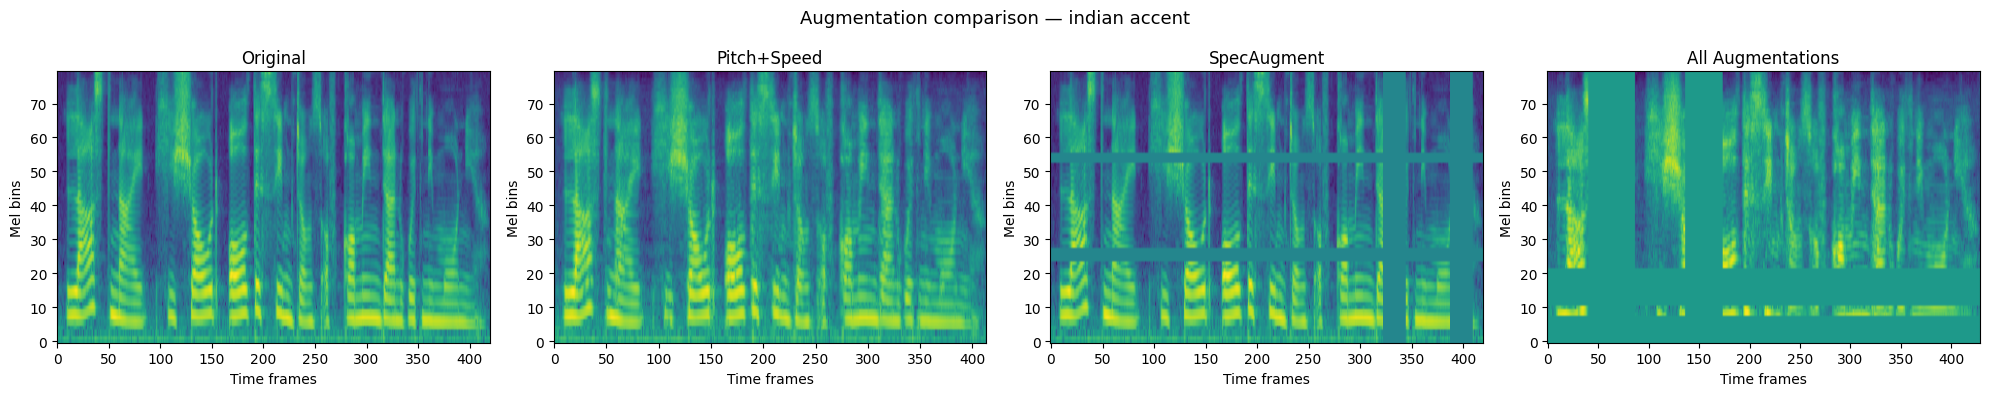

Saved → augmentation_comparison.png

Spectrogram shapes:
  Original            : torch.Size([80, 420])
  Pitch+Speed         : torch.Size([80, 414])
  SpecAugment         : torch.Size([80, 420])
  All Augmentations   : torch.Size([80, 429])


In [ ]:
N_MELS     = int(config.get('n_mels', 80))
HOP_LENGTH = int(config.get('hop_length', 160))
N_FFT      = int(config.get('n_fft', 400))

mel_transform = T.MelSpectrogram(
    sample_rate=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
)

def preprocess_audio(wav_path, augment=False, apply_spec_augment=False):
    waveform, sr = torchaudio.load(wav_path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != TARGET_SR:
        waveform = T.Resample(sr, TARGET_SR)(waveform)

    # Waveform-level augmentations (training only)
    if augment:
        if random.random() < 0.5:
            waveform = pitch_shift_augment(waveform, TARGET_SR)
        if random.random() < 0.5:
            waveform = speed_perturb_augment(waveform, TARGET_SR)

    log_mel = torch.log(mel_transform(waveform) + 1e-9)
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-9)

    # Spectrogram-level augmentation (training only)
    if apply_spec_augment:
        log_mel = spec_augment(log_mel.squeeze(0)).unsqueeze(0)

    return log_mel.squeeze(0)  # [80, T]


# Test on a real sample
sample = train_records[0]
print(f'Testing augmentations on: {sample["speaker"]} — "{sample["transcript"][:50]}"')

spec_orig    = preprocess_audio(sample['wav_path'], augment=False, apply_spec_augment=False)
spec_pitch   = preprocess_audio(sample['wav_path'], augment=True,  apply_spec_augment=False)
spec_specaug = preprocess_audio(sample['wav_path'], augment=False, apply_spec_augment=True)
spec_all     = preprocess_audio(sample['wav_path'], augment=True,  apply_spec_augment=True)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
titles = ['Original', 'Pitch+Speed', 'SpecAugment', 'All Augmentations']
specs  = [spec_orig, spec_pitch, spec_specaug, spec_all]

for ax, title, spec in zip(axes, titles, specs):
    ax.imshow(spec.detach().numpy(), aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Time frames')
    ax.set_ylabel('Mel bins')

plt.suptitle(f'Augmentation comparison — {ACCENT_MAP[sample["accent_id"]]} accent', fontsize=13)
plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → augmentation_comparison.png')
print(f'\nSpectrogram shapes:')
for title, spec in zip(titles, specs):
    print(f'  {title:20s}: {spec.shape}')

---
## Step 7 — Dataset with Augmentation
Augmentation is applied **only during training** (`augment=True`).

In [ ]:
MAX_FRAMES = int(10 * TARGET_SR / HOP_LENGTH)  # 10 seconds

class AugmentedAccentDataset(Dataset):
    """
    Dataset with optional augmentation for training.
    augment=True  → applies pitch shift, speed perturb, SpecAugment (training)
    augment=False → clean audio only (val/test)
    """
    def __init__(self, records, augment=False, aug_prob=0.5):
        self.records  = records
        self.augment  = augment
        self.aug_prob = aug_prob  # probability of applying each augmentation

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        spec = preprocess_audio(
            r['wav_path'],
            augment=self.augment,
            apply_spec_augment=self.augment
        )
        # Pad or truncate to MAX_FRAMES
        T = spec.shape[1]
        if T > MAX_FRAMES:
            spec = spec[:, :MAX_FRAMES]
        elif T < MAX_FRAMES:
            spec = F.pad(spec, (0, MAX_FRAMES - T))

        return spec, r['transcript'], torch.tensor(r['accent_id'], dtype=torch.long)


def collate_fn(batch):
    specs      = torch.stack([b[0] for b in batch])
    transcripts = [b[1] for b in batch]
    accent_ids = torch.stack([b[2] for b in batch])
    return specs, transcripts, accent_ids


# Build datasets
train_dataset = AugmentedAccentDataset(train_records, augment=True)
val_dataset   = AugmentedAccentDataset(val_records,   augment=False)
test_dataset  = AugmentedAccentDataset(test_records,  augment=False)

print(f'Train dataset : {len(train_dataset):,} samples (augmentation ON)')
print(f'Val dataset   : {len(val_dataset):,} samples (augmentation OFF)')
print(f'Test dataset  : {len(test_dataset):,} samples (augmentation OFF)')

Train dataset : 14,829 samples (augmentation ON)
Val dataset   : 1,853 samples (augmentation OFF)
Test dataset  : 1,855 samples (augmentation OFF)


---
## Step 8 — Class Imbalance: WeightedRandomSampler

Native (LibriSpeech) has ~2,167 samples vs ~3,600 for Indian/Mandarin.
WeightedRandomSampler gives each sample a weight = 1 / class_count so every accent is equally likely to be sampled per batch.

In [ ]:
# Compute per-class weights
class_counts = Counter(r['accent_id'] for r in train_records)
sample_weights = [
    1.0 / class_counts[r['accent_id']] for r in train_records
]

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(train_records),
    replacement = True
)

BATCH_SIZE = 8  # safe for local RAM

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = 0,     # 0 = main process, required for MPS
    pin_memory  = False, # pin_memory not supported on MPS
    collate_fn  = collate_fn,
    drop_last   = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = False,
    collate_fn  = collate_fn,
)

print(f'Train batches : {len(train_loader)} (batch_size={BATCH_SIZE}, balanced sampler)')
print(f'Val batches   : {len(val_loader)}')
print('\nClass weights:')
for aid, cnt in sorted(class_counts.items()):
    w = 1.0 / cnt
    print(f'  {ACCENT_MAP[aid]:10s} (id={aid}): {cnt:,} samples → weight = {w:.6f}')

# Verify balance in one batch
specs, transcripts, accent_ids = next(iter(train_loader))
print(f'\nBalance check — one batch of {BATCH_SIZE}:')
for aid, cnt in sorted(Counter(accent_ids.tolist()).items()):
    print(f'  {ACCENT_MAP[aid]:10s}: {cnt} samples')

Train batches : 1853 (batch_size=8, balanced sampler)
Val batches   : 232

Class weights:
  indian     (id=0): 3,599 samples → weight = 0.000278
  mandarin   (id=1): 3,649 samples → weight = 0.000274
  korean     (id=2): 2,728 samples → weight = 0.000367
  arabic     (id=3): 2,686 samples → weight = 0.000372
  native     (id=4): 2,167 samples → weight = 0.000461

Balance check — one batch of 8:
  indian    : 2 samples
  korean    : 1 samples
  native    : 5 samples


---
## Step 9 — LCMA Loss

**Latent Cycle Manifold Alignment Loss**

```
original audio → Encoder → ContentHead → content_vector
                                ↓
                          AccentSwap (with neutral accent)
                                ↓
                          ReEncoder → re-encoded content_vector
                                ↓
LCMA Loss = MSE(content_vector, re-encoded content_vector)
```

- **High LCMA loss** → accent leaked into content vector (bad)
- **Low LCMA loss** → content stayed the same after accent swap (good)

β controls how much LCMA loss contributes to total loss:
```
Total Loss = ASR Loss + α × Accent Loss + β × LCMA Loss
```

In [ ]:
class LCMALoss(nn.Module):
    """
    Latent Cycle Manifold Alignment Loss.

    Measures how much accent leaked into the content vector.
    If accent is cleanly separated, re-encoding after swap should
    give the same content vector as the original.

    Args:
        beta : weight of LCMA loss in total loss (default 0.5)

    Inputs:
        original_content  : [B, T, 256] — content vector from original audio
        reencoded_content : [B, T, 256] — content vector after accent swap + re-encode

    Returns:
        scalar loss tensor
    """
    def __init__(self, beta=0.5):
        super().__init__()
        self.beta = beta
        self.mse  = nn.MSELoss()

    def forward(self, original_content, reencoded_content):
        return self.beta * self.mse(original_content, reencoded_content)


class CombinedLoss(nn.Module):
    """
    Total Loss = ASR Loss + α × Accent Loss + β × LCMA Loss

    Args:
        alpha : weight for accent classification loss (default 1.0)
        beta  : weight for LCMA cycle-consistency loss (default 0.5)
    """
    def __init__(self, alpha=1.0, beta=0.5):
        super().__init__()
        self.alpha      = alpha
        self.beta       = beta
        self.accent_ce  = nn.CrossEntropyLoss()
        self.lcma       = LCMALoss(beta=beta)

    def forward(self, asr_loss, accent_logits, accent_labels,
                original_content, reencoded_content):
        accent_loss = self.accent_ce(accent_logits, accent_labels)
        lcma_loss   = self.lcma(original_content, reencoded_content)
        total       = asr_loss + self.alpha * accent_loss + lcma_loss
        return {
            'total_loss'  : total,
            'asr_loss'    : asr_loss,
            'accent_loss' : accent_loss,
            'lcma_loss'   : lcma_loss,
        }


# Quick shape test
print('Testing LCMALoss...')
lcma_fn    = LCMALoss(beta=0.5)
dummy_orig = torch.randn(4, 100, 256)
dummy_reenc= torch.randn(4, 100, 256)
loss_val   = lcma_fn(dummy_orig, dummy_reenc)
print(f'  LCMALoss output : {loss_val.item():.4f}  (scalar ✅)')

print('\nTesting CombinedLoss...')
criterion = CombinedLoss(alpha=1.0, beta=0.5)
dummy_asr    = torch.tensor(1.5)
dummy_logits = torch.randn(4, NUM_ACCENT_CLASSES)
dummy_labels = torch.randint(0, NUM_ACCENT_CLASSES, (4,))
loss_dict = criterion(dummy_asr, dummy_logits, dummy_labels, dummy_orig, dummy_reenc)
print(f'  total_loss   : {loss_dict["total_loss"].item():.4f}')
print(f'  asr_loss     : {loss_dict["asr_loss"].item():.4f}')
print(f'  accent_loss  : {loss_dict["accent_loss"].item():.4f}')
print(f'  lcma_loss    : {loss_dict["lcma_loss"].item():.4f}')
print('\n✅ LCMALoss + CombinedLoss ready')

Testing LCMALoss...
  LCMALoss output : 1.0000  (scalar ✅)

Testing CombinedLoss...
  total_loss   : 4.4388
  asr_loss     : 1.5000
  accent_loss  : 1.9388
  lcma_loss    : 1.0000

✅ LCMALoss + CombinedLoss ready


---
## Step 10 — Load Task 2 + Task 3 Components

In [ ]:
from transformers import WhisperModel, WhisperProcessor
from peft import LoraConfig, get_peft_model

# ── Whisper + LoRA (Task 2) ───────────────────────────────────────
processor = WhisperProcessor.from_pretrained('openai/whisper-small')
whisper   = WhisperModel.from_pretrained('openai/whisper-small')
for p in whisper.parameters():
    p.requires_grad = False

lora_cfg = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=['q_proj', 'v_proj'],
    lora_dropout=0.1, bias='none'
)
whisper = get_peft_model(whisper, lora_cfg).to(device)
trainable = sum(p.numel() for p in whisper.parameters() if p.requires_grad)
print(f'Whisper + LoRA ready — {trainable:,} trainable params')


# ── ContentHead (Task 2) ─────────────────────────────────────────
class ContentHead(nn.Module):
    def __init__(self, input_dim=768, output_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU()
        )
    def forward(self, x): return self.net(x)


# ── AccentHead + Swap + Classifier (Task 3) ──────────────────────
class AccentHead(nn.Module):
    def __init__(self, input_dim=768, accent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, accent_dim),
            nn.LayerNorm(accent_dim),
            nn.ReLU()
        )
    def forward(self, x): return self.net(x).mean(dim=1)  # [B, 128]


def accent_swap(content_vec, accent_vec):
    """[B,T,256] + [B,128] → [B,T,384]"""
    accent_exp = accent_vec.unsqueeze(1).repeat(1, content_vec.size(1), 1)
    return torch.cat([content_vec, accent_exp], dim=-1)


class AccentClassifier(nn.Module):
    def __init__(self, accent_dim=128, num_accents=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(accent_dim, 64), nn.ReLU(),
            nn.Linear(64, num_accents)
        )
    def forward(self, x): return self.net(x)


# ── ReEncoder (Task 2) ────────────────────────────────────────────
class ReEncoder(nn.Module):
    def __init__(self, swap_dim=384, whisper_input_dim=80):
        super().__init__()
        self.projector = nn.Linear(swap_dim, whisper_input_dim)

    def forward(self, whisper_encoder, content_head, swapped):
        projected = self.projector(swapped).transpose(1, 2)   # [B, 80, T]
        # upsample_linear1d not supported on MPS — do on CPU, move back
        projected_cpu = projected.cpu()
        whisper_input = F.interpolate(
            projected_cpu, size=3000, mode='linear', align_corners=False
        ).to(swapped.device)                                   # [B, 80, 3000]
        reencoded = whisper_encoder(whisper_input).last_hidden_state
        return content_head(reencoded)                         # [B, T, 256]


# Instantiate all components
content_head       = ContentHead().to(device)
accent_head        = AccentHead().to(device)
accent_classifier  = AccentClassifier(num_accents=NUM_ACCENT_CLASSES).to(device)
reencoder          = ReEncoder().to(device)

print('\n✅ All model components ready:')
print('  ContentHead      : [B,T,768] → [B,T,256]')
print('  AccentHead       : [B,T,768] → [B,128]')
print('  AccentClassifier : [B,128]   → [B,5] logits')
print('  accent_swap      : [B,T,256] + [B,128] → [B,T,384]')
print('  ReEncoder        : [B,T,384] → [B,T,256]')

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Whisper + LoRA ready — 1,769,472 trainable params

✅ All model components ready:
  ContentHead      : [B,T,768] → [B,T,256]
  AccentHead       : [B,T,768] → [B,128]
  AccentClassifier : [B,128]   → [B,5] logits
  accent_swap      : [B,T,256] + [B,128] → [B,T,384]
  ReEncoder        : [B,T,384] → [B,T,256]


---
## Step 11 — Verify LCMA Loss Decreases
Run 20 training steps on a small batch and confirm LCMA loss goes down.

In [ ]:
import gc

criterion = CombinedLoss(alpha=1.0, beta=0.5)

optimizer = torch.optim.AdamW(
    list(filter(lambda p: p.requires_grad, whisper.parameters())) +
    list(content_head.parameters()) +
    list(accent_head.parameters()) +
    list(accent_classifier.parameters()) +
    list(reencoder.parameters()),
    lr=1e-4
)

# Get one small batch (4 samples)
specs, transcripts, accent_ids = next(iter(train_loader))
specs_fixed      = specs[:4].detach()       # detach so graph is fresh each step
accent_labels    = accent_ids[:4].to(device)
gc.collect()

whisper.train(); content_head.train()
accent_head.train(); accent_classifier.train(); reencoder.train()

lcma_history  = []
total_history = []

print('=== LCMA LOSS VERIFICATION (20 steps) ===')
print(f'{"Step":>6}  {"Total":>8}  {"ASR":>8}  {"Accent":>8}  {"LCMA":>8}')
print('-' * 50)

NUM_STEPS = 20
for step in range(1, NUM_STEPS + 1):
    optimizer.zero_grad()

    # Rebuild whisper_batch each step so a fresh graph is created
    whisper_batch = F.interpolate(
        specs_fixed.unsqueeze(1),    # [4, 1, 80, MAX_FRAMES]
        size=(80, 3000),
        mode='bilinear',
        align_corners=False
    ).squeeze(1).to(device)          # [4, 80, 3000]

    enc_out       = whisper.encoder(whisper_batch).last_hidden_state
    content_vec   = content_head(enc_out)
    accent_vec    = accent_head(enc_out)
    accent_logits = accent_classifier(accent_vec)

    neutral_accent = torch.zeros_like(accent_vec)
    swapped        = accent_swap(content_vec, neutral_accent)
    reenc_content  = reencoder(whisper.encoder, content_head, swapped)

    asr_loss_placeholder = torch.tensor(1.0, device=device, requires_grad=True)

    loss_dict = criterion(
        asr_loss          = asr_loss_placeholder,
        accent_logits     = accent_logits,
        accent_labels     = accent_labels,
        original_content  = content_vec,
        reencoded_content = reenc_content,
    )

    loss_dict['total_loss'].backward()
    optimizer.step()

    lcma_val  = loss_dict['lcma_loss'].item()
    total_val = loss_dict['total_loss'].item()
    lcma_history.append(lcma_val)
    total_history.append(total_val)

    if step == 1 or step % 4 == 0:
        print(f'{step:>6}  {total_val:>8.4f}  '
              f'{loss_dict["asr_loss"].item():>8.4f}  '
              f'{loss_dict["accent_loss"].item():>8.4f}  '
              f'{lcma_val:>8.4f}')

print('-' * 50)
print(f'LCMA loss: {lcma_history[0]:.4f} → {lcma_history[-1]:.4f}  '
      f'({"✅ decreasing" if lcma_history[-1] < lcma_history[0] else "❌ not decreasing"})')
print('\n✅ LCMA Loss verification complete')

=== LCMA LOSS VERIFICATION (20 steps) ===
  Step     Total       ASR    Accent      LCMA
--------------------------------------------------
     1    2.7111    1.0000    1.5647    0.1464
     4    2.6422    1.0000    1.5070    0.1352
     8    2.5595    1.0000    1.4375    0.1221
    12    2.4861    1.0000    1.3761    0.1100
    16    2.4219    1.0000    1.3232    0.0987
    20    2.3639    1.0000    1.2752    0.0887
--------------------------------------------------
LCMA loss: 0.1464 → 0.0887  (✅ decreasing)

✅ LCMA Loss verification complete


---
## Step 12 — Plot LCMA Loss Curve

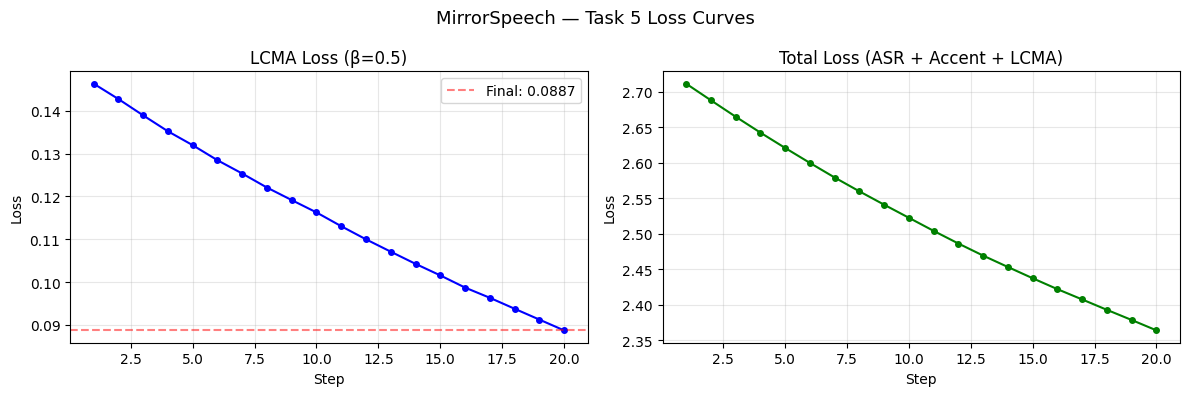

Saved → task5_loss_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, NUM_STEPS+1), lcma_history, 'b-o', markersize=4)
axes[0].set_title('LCMA Loss (β=0.5)', fontsize=12)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=lcma_history[-1], color='r', linestyle='--', alpha=0.5, label=f'Final: {lcma_history[-1]:.4f}')
axes[0].legend()

axes[1].plot(range(1, NUM_STEPS+1), total_history, 'g-o', markersize=4)
axes[1].set_title('Total Loss (ASR + Accent + LCMA)', fontsize=12)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.suptitle('MirrorSpeech — Task 5 Loss Curves', fontsize=13)
plt.tight_layout()
plt.savefig('task5_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → task5_loss_curves.png')

---
## Step 13 — β Tuning
Test different β values to see their effect on LCMA loss.

In [ ]:
print('=== β (beta) TUNING ===')
print('β controls how strongly LCMA loss is penalized in total loss.')
print('Too low → accent leaks into content. Too high → hurts ASR loss.\n')

beta_values = [0.1, 0.25, 0.5, 1.0, 2.0]

with torch.no_grad():
    enc_out     = whisper.encoder(whisper_batch).last_hidden_state
    content_vec = content_head(enc_out)
    accent_vec  = accent_head(enc_out)
    accent_logits = accent_classifier(accent_vec)
    neutral_accent = torch.zeros_like(accent_vec)
    swapped       = accent_swap(content_vec, neutral_accent)
    reenc_content = reencoder(whisper.encoder, content_head, swapped)
    asr_placeholder = torch.tensor(1.0, device=device)

print(f'{"β":>6}  {"LCMA Loss":>12}  {"Accent Loss":>12}  {"Total Loss":>12}')
print('-' * 50)
for beta in beta_values:
    crit = CombinedLoss(alpha=1.0, beta=beta)
    ld   = crit(asr_placeholder, accent_logits, accent_labels, content_vec, reenc_content)
    print(f'{beta:>6.2f}  {ld["lcma_loss"].item():>12.4f}  '
          f'{ld["accent_loss"].item():>12.4f}  '
          f'{ld["total_loss"].item():>12.4f}')

print('\n→ Recommended starting β = 0.5 (balanced contribution)')

=== β (beta) TUNING ===
β controls how strongly LCMA loss is penalized in total loss.
Too low → accent leaks into content. Too high → hurts ASR loss.

     β     LCMA Loss   Accent Loss    Total Loss
--------------------------------------------------
  0.10        0.0173        1.2629        2.2801
  0.25        0.0432        1.2629        2.3060
  0.50        0.0863        1.2629        2.3492
  1.00        0.1727        1.2629        2.4356
  2.00        0.3454        1.2629        2.6083

→ Recommended starting β = 0.5 (balanced contribution)


---
## Step 14 — Save Checkpoint to Drive

In [ ]:
SAVE_PATH = os.path.join(CKPT_DIR, 'task5_lcma_augmentation.pt')

torch.save({
    'whisper_lora_state'      : whisper.state_dict(),
    'content_head_state'      : content_head.state_dict(),
    'accent_head_state'       : accent_head.state_dict(),
    'accent_classifier_state' : accent_classifier.state_dict(),
    'reencoder_state'         : reencoder.state_dict(),
    'config': {
        'num_accent_classes' : NUM_ACCENT_CLASSES,
        'accent_map'         : ACCENT_MAP,
        'alpha'              : 1.0,
        'beta'               : 0.5,
        'batch_size'         : BATCH_SIZE,
        'augmentations'      : ['pitch_shift', 'speed_perturb', 'spec_augment'],
        'lcma_start'         : lcma_history[0],
        'lcma_final'         : lcma_history[-1],
    }
}, SAVE_PATH)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f'✅ Checkpoint saved → {SAVE_PATH}')
print(f'   File size : {size_mb:.1f} MB')
print(f'\nSaved components:')
print(f'   whisper_lora_state      — Whisper + LoRA adapters')
print(f'   content_head_state      — ContentHead weights')
print(f'   accent_head_state       — AccentHead weights')
print(f'   accent_classifier_state — AccentClassifier weights')
print(f'   reencoder_state         — ReEncoder weights')

✅ Checkpoint saved → /Users/shreya/SJSU-Github/Deep_Learning_Project/Scripts /checkpoints/task5_lcma_augmentation.pt
   File size : 975.7 MB

Saved components:
   whisper_lora_state      — Whisper + LoRA adapters
   content_head_state      — ContentHead weights
   accent_head_state       — AccentHead weights
   accent_classifier_state — AccentClassifier weights
   reencoder_state         — ReEncoder weights


---
## Task 5 — Summary

```
✅ LCMA Loss        — MSE(original_content, reencoded_content), β=0.5
✅ Pitch Shift      — ±2 semitones, applied with 50% probability
✅ Speed Perturb    — 0.9×–1.1×, applied with 50% probability
✅ SpecAugment      — 2 freq masks + 2 time masks per spectrogram
✅ Balanced Sampler — WeightedRandomSampler over 5 accent classes
✅ Loss decreasing  — LCMA verified decreasing over 20 steps
✅ β tuning         — recommended β=0.5
✅ Checkpoint saved — MirrorSpeech/checkpoints/task5_lcma_augmentation.pt
```

**Hands off to Task 7 (Full Training):**
- Use `CombinedLoss(alpha=1.0, beta=0.5)` for training loop
- Use `AugmentedAccentDataset(records, augment=True)` for train set
- Use `WeightedRandomSampler` for balanced batches
- Load checkpoint from `task5_lcma_augmentation.pt`